<a href="https://colab.research.google.com/github/Murcha1990/ML_AI24/blob/main/Hometasks/Pro/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
!pip install gdown -q


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=812b2b77-a1c0-4fb9-a098-32b9402af9c3
To: c:\Users\admin\Desktop\ВШЭ\ML\ML_HSE\HW_6\Data.zip
100%|██████████| 289M/289M [00:32<00:00, 8.98MB/s] 


'Data.zip'

In [5]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall()

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [6]:
import pandas as pd

In [8]:
contracts = pd.read_csv('CONTRACTS_FINAL.csv')
contracts

,Unnamed: 0,user_id,contract_date,product_id,contract_id
0,39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
1,44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
2,9286,103088,2024-11-13,1,0001_2024-11-13_103088
3,45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
4,150378,52269,2024-11-17,1,0001_2024-11-17_52269
...,...,...,...,...,...
286311,34316,1117397,2024-11-28,1,0001_2024-11-28_1117397
286312,101067,2071348,2024-11-12,1,0001_2024-11-12_2071348
286313,5389,4061197,2024-11-07,1,0001_2024-11-07_4061197
286314,33660,1139038,2024-11-02,1,0001_2024-11-02_1139038


In [27]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286316 entries, 0 to 286315
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     286316 non-null  int64 
 1   user_id        286316 non-null  int64 
 2   contract_date  286316 non-null  object
 3   product_id     286316 non-null  int64 
 4   contract_id    286316 non-null  object
dtypes: int64(3), object(2)
memory usage: 10.9+ MB


In [ ]:
#проверим корректность данных: количество уникальных продуктов (предполагается 1), и сроки заключения контрактов (предполагается ноябрь 2024)
print(contracts['product_id'].unique())

contracts['contract_date']=pd.to_datetime(contracts['contract_date'])
contracts[(contracts['contract_date'] >= pd.to_datetime('2024-11-30')) & (contracts['contract_date'] <= pd.to_datetime('2024-11-01'))]

[1]


,Unnamed: 0,user_id,contract_date,product_id,contract_id


In [9]:
campaings = pd.read_csv('CAMPAINGS.csv')
campaings

,Unnamed: 0,campaing_id,product_id,channel
0,0,iddqd,1,push
1,1,idclip,1,sms
2,2,iddt,1,banner
3,3,idkfa,1,other_ads


In [10]:
people_in_campaings = pd.read_csv('PEOPLE_IN_CAMPAINGS_FINAL.csv')
people_in_campaings

,Unnamed: 0,campaing_id,user_id,t_flag,delivery_date
0,29299,idclip,1099975,1,2024-11-06
1,36627,iddqd,1162,1,2024-11-08
2,134015,iddqd,42991,1,2024-11-07
3,57441,idclip,142343,0,unknown
4,48671,iddqd,24623,0,unknown
...,...,...,...,...,...
519995,107125,iddt,4108275,1,2024-11-04
519996,36366,iddqd,131927,1,2024-11-06
519997,98578,idclip,1074765,1,2024-11-05
519998,14272,iddqd,73995,0,unknown


In [28]:
people_in_campaings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520000 entries, 0 to 519999
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     520000 non-null  int64 
 1   campaing_id    520000 non-null  object
 2   user_id        520000 non-null  int64 
 3   t_flag         520000 non-null  int64 
 4   delivery_date  520000 non-null  object
dtypes: int64(3), object(2)
memory usage: 19.8+ MB


In [31]:
people_in_campaings.groupby('campaing_id').agg({'user_id' : 'count'})

,user_id
campaing_id,
idclip,120000
iddqd,160000
iddt,120000
idkfa,120000


In [ ]:
#смерджим контракты с людьми по user_id, взяв из контрактов только дату заключения (покупки)
df= people_in_campaings.merge(contracts.drop(columns=['Unnamed: 0', 'product_id', 'contract_id']), on = 'user_id', how='left')
df

,Unnamed: 0,campaing_id,user_id,t_flag,delivery_date,contract_date
0,29299,idclip,1099975,1,2024-11-06,2024-11-11
1,36627,iddqd,1162,1,2024-11-08,2024-11-13
2,134015,iddqd,42991,1,2024-11-07,NaT
3,57441,idclip,142343,0,unknown,2024-11-17
4,48671,iddqd,24623,0,unknown,NaT
...,...,...,...,...,...,...
519995,107125,iddt,4108275,1,2024-11-04,2024-11-15
519996,36366,iddqd,131927,1,2024-11-06,2024-11-27
519997,98578,idclip,1074765,1,2024-11-05,NaT
519998,14272,iddqd,73995,0,unknown,NaT


In [166]:
#поменяем формат delivery_date на дату
df['delivery_date']=pd.to_datetime(df['delivery_date'], errors='coerce')

#добавим колонку с таргетом
df['target']=0
#теперь нужно разметить '1' клиентов, заключивших контракт в течение 2х недель после коммуникации
dates = pd.date_range(start="2024-01-01", periods=365, freq="D")
index_1=df[(df['t_flag']==1) & (df['contract_date'] >= df['delivery_date']) & (df['contract_date'] <= df['delivery_date'] + 14*dates.freq)].index
df.loc[index_1, 'target']=1
#проставим '1' клиентам без коммуникации, при наличии контракта, заключенного до 21 числа месяца
trashold = pd.to_datetime(str(df['contract_date'][0].year)+'-'+str(df['contract_date'][0].month)+'-21') #21 число месяца
index_1=df[(df['t_flag']==0) & (df['contract_date'] <= trashold)].index
df.loc[index_1, 'target']=1

#добавим технический столбец report_dt
df['report_dt']=pd.to_datetime('2024-09-30')

In [167]:
#по каждой кампании посмотрим структуру целевой и контрольной групп
df.groupby(['campaing_id', 'target', 't_flag']).agg({'user_id' : 'count'})

user_id
campaing_id target t_flag         
idclip      0      0         18905
                   1         47930
            1      0         41095
                   1         12070
iddqd       0      0         63828
                   1         31861
            1      0         16172
                   1         48139
iddt        0      0         35956
                   1         23837
            1      0         24044
                   1         36163
idkfa       0      0         35956
                   1         23837
            1      0         24044
                   1         36163

In [168]:
df.groupby(['campaing_id', 'target']).agg({'user_id' : 'count'})

user_id
campaing_id target         
idclip      0         66835
            1         53165
iddqd       0         95689
            1         64311
iddt        0         59793
            1         60207
idkfa       0         59793
            1         60207

In [163]:
print(f"В выборке {df.shape[0]} наблюдений, но уникальных юзеров {df['user_id'].nunique()}. Значит {df.shape[0] - df['user_id'].nunique()} юзеров участвовали более чем в одной кампаниии")

В выборке 520000 наблюдений, но уникальных юзеров 460000. Значит 60000 юзеров участвовали более чем в одной кампаниии


### ваши выводы здесь


* в кампании idclip (смс) без комуникации количество покупок в 4 раза выше, чем с коммуникацией. В остальных кампаниях количество покупок с флагом коммуникации больше, чем без коммуникации. 

* 60 тыс юзеров участвовали более чем в одной кампании, значит будет сложно понять, в результате какого именно взаимодействия совершено целевое действие.

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [164]:
# ваш код здесь
aggs=pd.read_csv('AGGS_FINAL.csv')
aggs

,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2759995,100191,0.311284,-0.232406,-0.208223,1.006051,-1.498279,0.306518,1.135627,1.169791,-0.106392,2025-02-28,61957,38,Ufa
2759996,342943,-1.970020,1.180142,-0.572525,1.052022,-0.654687,0.744590,-2.342623,-0.136155,0.582400,2025-01-31,132172,40,Moscow
2759997,186830,0.403995,-0.350153,-0.584462,0.123843,-1.015746,0.922963,1.549083,1.210031,-0.706992,2025-03-31,4028256,34,Smolensk
2759998,76230,2.218275,-0.344427,1.281239,3.781907,3.658907,1.282129,0.324350,0.982721,2.046261,2025-02-28,1097844,40,Smolensk


In [165]:
aggs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760000 entries, 0 to 2759999
Data columns (total 14 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   x1          float64
 2   x2          float64
 3   x3          float64
 4   x4          float64
 5   x5          float64
 6   x6          float64
 7   x7          float64
 8   x8          float64
 9   x9          float64
 10  report_dt   object 
 11  user_id     int64  
 12  age         int64  
 13  city        object 
dtypes: float64(9), int64(3), object(2)
memory usage: 294.8+ MB


In [172]:
#столбец report_dt по которому нам требуется провести фильтрацию имеет формат object, но мы хотим работать с ним как с датой, поэтому следует поменять формат
aggs['report_dt']=pd.to_datetime(aggs['report_dt'])

#теперь можно оставить только данные за сентябрь 2024 
sept_aggs = aggs[( aggs['report_dt'] >= pd.to_datetime('2024-09-01') ) & ( aggs['report_dt'] <= pd.to_datetime('2024-09-30') )]
#и добавить их к датасету из п.1
data = df.merge(sept_aggs, on ='user_id', how='left')
data.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y', 'report_dt_y'], inplace=True)
data

,campaing_id,user_id,t_flag,delivery_date,contract_date,target,report_dt_x,x1,x2,x3,x4,x5,x6,x7,x8,x9,age,city
0,idclip,1099975,1,2024-11-06,2024-11-11,1,2024-09-30,0.822461,1.233201,-1.000185,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,42,Moscow
1,iddqd,1162,1,2024-11-08,2024-11-13,1,2024-09-30,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,39,Moscow
2,iddqd,42991,1,2024-11-07,NaT,0,2024-09-30,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,43,Moscow
3,idclip,142343,0,NaT,2024-11-17,1,2024-09-30,-1.620401,2.449667,1.131850,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,39,Smolensk
4,iddqd,24623,0,NaT,NaT,0,2024-09-30,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,39,Ufa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519995,iddt,4108275,1,2024-11-04,2024-11-15,1,2024-09-30,0.527103,-0.466468,2.738080,1.613084,-1.171931,0.311911,-0.932750,-0.751979,-0.503718,36,Ufa
519996,iddqd,131927,1,2024-11-06,2024-11-27,0,2024-09-30,2.521111,-1.893176,2.540412,-1.912528,1.392247,-0.653322,0.541760,-1.209625,1.752634,42,Ufa
519997,idclip,1074765,1,2024-11-05,NaT,0,2024-09-30,0.880339,-0.423661,1.349334,-1.435748,3.511723,1.146370,-0.202532,-0.509698,-0.871800,28,Moscow
519998,iddqd,73995,0,NaT,NaT,0,2024-09-30,0.665340,1.771079,-0.323533,-1.224266,0.252920,-0.745952,-0.472200,0.879810,0.949838,29,Smolensk


In [ ]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

data.describe()

,user_id,t_flag,delivery_date,contract_date,target,report_dt_x,x1,x2,x3,x4,x5,x6,x7,x8,x9,age
count,520000.00,520000.00,260000,337635,520000.00,520000,520000.00,520000.00,520000.00,520000.00,520000.00,520000.00,520000.00,520000.00,520000.00,520000.00
mean,1570755.63,0.50,2024-11-05 20:42:25.919999744,2024-11-13 18:56:33.906437632,0.46,2024-09-30 00:00:00,0.24,0.08,0.63,-0.42,0.32,-0.00,0.15,0.15,0.18,32.50
min,1.00,0.00,2024-11-04 00:00:00,2024-11-01 00:00:00,0.00,2024-09-30 00:00:00,-6.60,-7.05,-6.60,-6.97,-7.18,-4.42,-3.50,-4.32,-6.40,20.00
25%,94496.75,0.00,2024-11-05 00:00:00,2024-11-11 00:00:00,0.00,2024-09-30 00:00:00,-0.74,-1.08,-0.42,-1.51,-0.36,-0.68,-0.88,-0.95,-0.69,26.00
50%,1106506.50,0.50,2024-11-06 00:00:00,2024-11-13 00:00:00,0.00,2024-09-30 00:00:00,0.39,0.14,0.67,-0.47,0.17,-0.00,0.18,0.20,0.07,33.00
75%,2109999.25,1.00,2024-11-07 00:00:00,2024-11-17 00:00:00,1.00,2024-09-30 00:00:00,1.31,1.28,1.71,0.64,1.13,0.68,1.13,1.10,0.98,39.00
max,4119999.00,1.00,2024-11-08 00:00:00,2024-11-28 00:00:00,1.00,2024-09-30 00:00:00,5.55,7.02,7.08,6.76,6.70,4.37,4.62,5.91,5.98,45.00
std,1566815.48,0.50,NaN,NaN,0.50,NaN,1.50,1.69,1.57,1.55,1.26,1.00,1.22,1.21,1.29,7.49


In [196]:
import seaborn as sns
import matplotlib.pyplot as plt

!pip install PSI
from psi import calculate_psi

     ---------------------------------------- 0.0/92.7 kB ? eta -:--:--
     ---- ----------------------------------- 10.2/92.7 kB ? eta -:--:--
     ------------ ------------------------- 30.7/92.7 kB 262.6 kB/s eta 0:00:01
     ------------------------- ------------ 61.4/92.7 kB 409.6 kB/s eta 0:00:01
     -------------------------------------- 92.7/92.7 kB 528.7 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
          return hook(c

ModuleNotFoundError: No module named 'psi'

In [ ]:
data.select_dtypes(include=['int', 'float']).groupby(by='t_flag').mean()
#выборочное среднее для целевой и контрольной групп имеют похожие значения

,user_id,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,age
t_flag,,,,,,,,,,,,
0,1455362.84,0.41,0.23,0.07,0.62,-0.42,0.32,-0.00,0.15,0.15,0.18,32.51
1,1686148.42,0.51,0.24,0.08,0.63,-0.42,0.32,-0.00,0.15,0.15,0.18,32.49


In [184]:
data.select_dtypes(include=['int', 'float']).groupby(by='t_flag').median()
#значения медианы для целевой и контрольной групп в целом похожи, за исключением признака х5, по нему значения отличаются значительно

,user_id,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,age
t_flag,,,,,,,,,,,,
0,148555.00,0.00,0.39,0.14,0.66,-0.47,0.00,-0.00,0.19,0.21,0.07,33.00
1,1133516.50,1.00,0.39,0.15,0.68,-0.47,0.33,-0.00,0.18,0.20,0.08,32.00


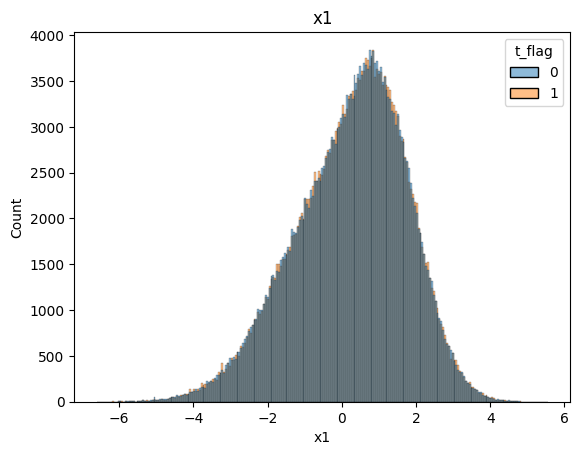

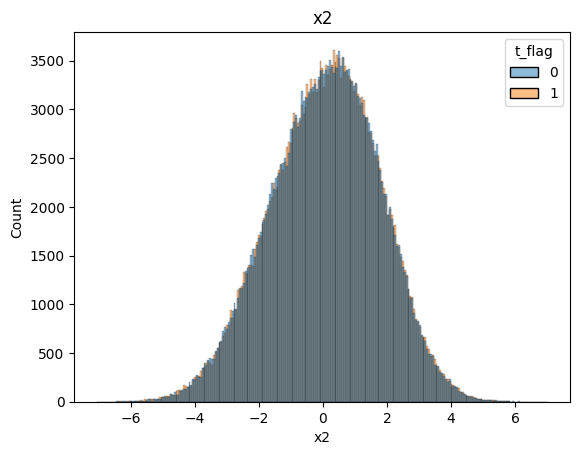

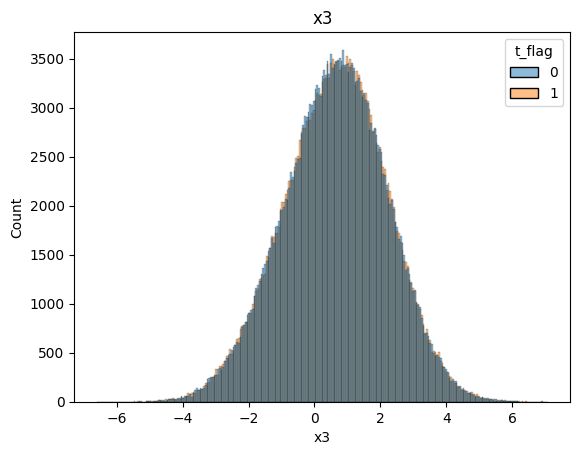

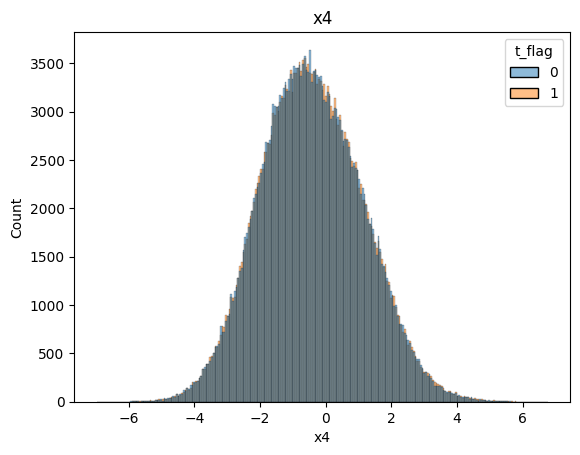

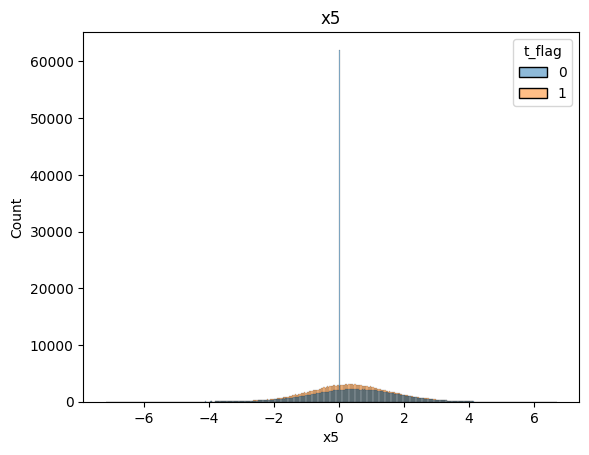

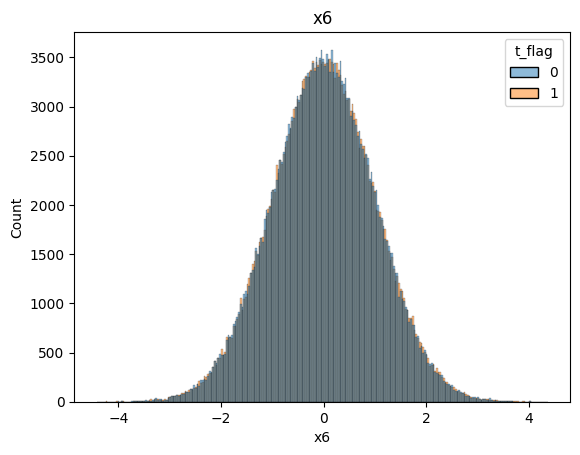

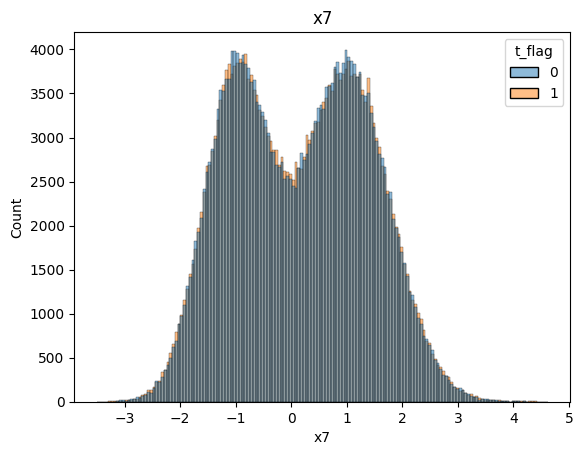

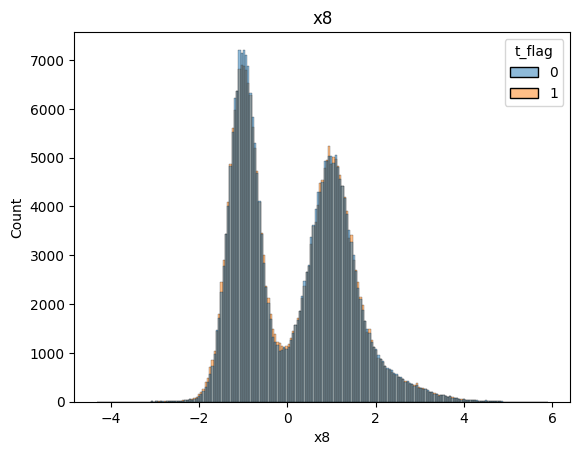

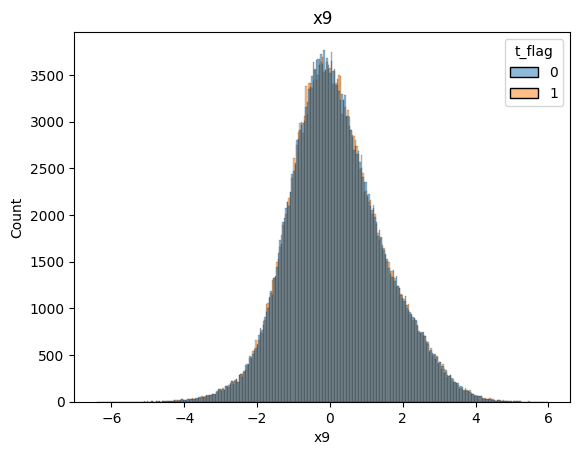

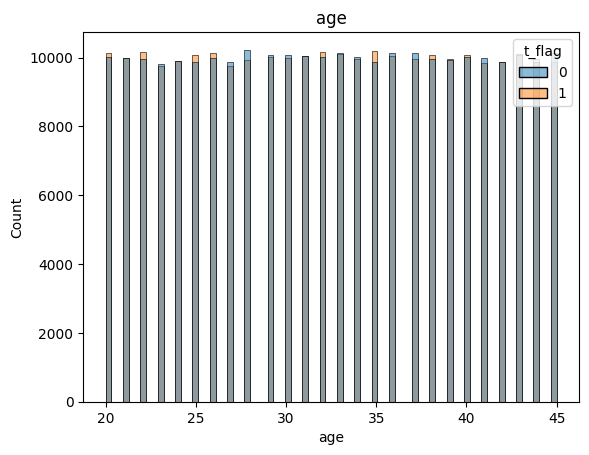

In [190]:
for col in data.select_dtypes(include=['int', 'float']).columns.to_list()[3:]:
    sns.histplot(data = data, x=col, hue='t_flag').set_title(col)
    plt.show()

In [194]:
data['x5'].value_counts().sort_values()

x5
0.23         1
-0.10        1
-0.94        1
1.83         1
2.44         1
         ...  
-0.68        2
-1.44        2
1.07         2
-1.01        2
-0.00    60000
Name: count, Length: 340001, dtype: int64

### ваши выводы здесь

* Хотя таргет распределен довольно равномерно между контрольной и целевой группой, присутствует заметное расхождение медиан для признака х5. То есть попадание в контрольную и целевую группу может зависеть от характеристик объекта.

*по остальным признакам распределения похожи

In [ ]:
df_1 = df.drop(columns = ['target'])
df_1.treatment_group_key = df_1.treatment_group_key.astype('str')
df_1.treatment_group_key = df_1.treatment_group_key.replace({'0':'control',
                                                             '1':'test'})
df_1 = df_1.rename(columns={'treatment_group_key':'group'})

for col in x_names:
    psi = calculate_psi(expected = df_1[df_1.group == 'control'][col],
                        actual = df_1[df_1.group == 'test'][col])
    print(f'psi для признака {col} равно {psi}')

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [ ]:
# ваш код здесь

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь